In [210]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [211]:

import os
# os.environ['CUDA_VISIBLE_DEVICES'] = "2"
# os.environ['TF_ENABLE_ONEDNN_OPTS'] = "0"
# from tensorflow.keras import layers
# from tensorflow import keras
# import tensorflow as tf

# from tensorflow.keras.applications.resnet50 import ResNet50
# from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
# importing relevant packages 

import torch 
from torchvision import models
import pandas as pd
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import glob
import os
import cv2
import matplotlib.pyplot as plt 
import torchvision.transforms as transforms
from torchsummary import summary
from sklearn.model_selection import train_test_split
import numpy as np
from tqdm import tqdm



In [212]:
from imgaug.augmentables.kps import KeypointsOnImage
from imgaug.augmentables.kps import Keypoint
import imgaug.augmenters as iaa

from PIL import Image
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import json
import os
import glob
from os import listdir


In [213]:
# downloading the data 
# !git clone https://github.com/udacity/P1_Facial_Keypoints.git
# !cd P1_Facial_Keypoints

root_dir = '/home/jc-merlab/Deep_Learning/merlab_dl_data/2D_proj_ds/'
all_img_paths = glob.glob(os.path.join(root_dir, '*.jpg'))

# data = pd.read_csv('/home/jc-merlab/Deep_Learning/merlab_dl_data/P1_Facial_Keypoints/data/training_frames_keypoints.csv')

data = pd.read_csv('all_kps_results.csv')

print(type(data))
doc = data.iloc[4221][1]

print(doc)

data.head(100)
# data.shape


<class 'pandas.core.frame.DataFrame'>
61.rgb.jpg


,id,image,keypoints/0/0,keypoints/0/1,keypoints/1/0,keypoints/1/1,keypoints/2/0,keypoints/2/1,keypoints/3/0,keypoints/3/1,keypoints/4/0,keypoints/4/1,keypoints/5/0,keypoints/5/1
0,4153,4153.rgb.jpg,179.557465,436.937679,171.265252,310.031251,84.654931,216.724791,110.961836,195.301360,95.871417,35.564257,78.686660,1.552745
1,2656,2656.rgb.jpg,179.557465,436.937679,171.265252,310.031251,55.652497,249.855611,73.301435,220.777993,55.347266,60.238411,37.384451,26.347229
2,4607,4607.rgb.jpg,179.557465,436.937679,171.265252,310.031251,109.045516,201.061825,139.244947,186.012770,211.343602,51.690734,214.750082,17.639519
3,2927,2927.rgb.jpg,179.557465,436.937679,171.265252,310.031251,267.509120,235.637465,286.037936,259.917192,415.601483,299.645708,443.824763,296.624461
4,427,427.rgb.jpg,179.557465,436.937679,171.265252,310.031251,94.767895,209.262904,123.031031,190.543028,259.283278,263.630292,289.259908,275.169626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,4136,4136.rgb.jpg,179.557465,436.937679,171.265252,310.031251,81.389713,219.463363,106.990584,197.180383,91.861397,37.205302,74.623992,3.138089
96,3156,3156.rgb.jpg,179.557465,436.937679,171.265252,310.031251,225.478383,200.797383,253.679464,214.935846,391.661955,194.152635,416.838258,178.827154
97,245,245.rgb.jpg,179.557465,436.937679,171.265252,310.031251,94.756396,209.270580,123.017610,190.547683,275.650069,212.878926,307.465028,213.523048
98,621,621.rgb.jpg,179.557465,436.937679,171.265252,310.031251,107.835076,201.646841,137.947143,186.361616,276.100525,251.763058,307.625290,253.842662


In [214]:

img_arr = cv2.imread(os.path.join(root_dir, '953.rgb.jpg'))

print(img_arr.shape)

img_arr = img_arr[:,:,::-1] 

# print(img_arr.shape)

(480, 640, 3)


In [215]:
x_points = data.iloc[14][2:][::2]
y_points = data.iloc[14][3:][::2]

print(x_points)
print(y_points)

keypoints/0/0    179.557465
keypoints/1/0    171.265252
keypoints/2/0    107.775151
keypoints/3/0    137.880069
keypoints/4/0    258.863181
keypoints/5/0    275.415553
Name: 14, dtype: object
keypoints/0/1    436.937679
keypoints/1/1    310.031251
keypoints/2/1    201.677329
keypoints/3/1    186.376499
keypoints/4/1      97.66601
keypoints/5/1     70.319113
Name: 14, dtype: object


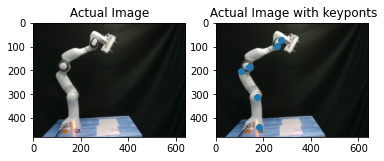

In [216]:
plt.subplot(121)
plt.imshow(img_arr)
plt.title(" Actual Image ")
plt.subplot(122)
plt.imshow(img_arr)
plt.scatter(list(x_points), list(y_points))
plt.title(" Actual Image with keyponts")
plt.show()

In [217]:
class KpDataset(Dataset):
    def __init__(self, df):
        super().__init__()
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])
        self.df = df

    def __getitem__(self, ix):
        doc = self.df.iloc[ix]
        image_name = doc[1]
        image_path = os.path.join(root_dir,image_name)  
        img_arr = cv2.imread(image_path)
        x_axis_points = doc[2:][::2]
        y_axis_points = doc[3:][::2]
        x_axis_points = list(x_axis_points/img_arr.shape[1])           # scaling the facial points with respective image_dim 
        y_axis_points = list(y_axis_points/img_arr.shape[0])           # so that we can use relative positions w.r.t image

        points = x_axis_points + y_axis_points  

        img_arr = img_arr/255.0                                                                 # scaling the image 
        img = self.preprocess_img(img_arr)

        return img.to(device), torch.tensor(points).to(device)

    def __len__(self):
        return self.df.shape[0]


    def preprocess_img(self, img):
        img = cv2.resize(img, (224,224)) 
        img = torch.tensor(img).permute(2,0,1) 
        img = self.normalize(img).float()
        return img

    def load_img(self, ix):
        doc = self.df.iloc[ix]
        img_name = doc[1]
        img = cv2.imread(os.path.join(root_dir, img_name))
        return img

In [218]:
train_df, rem_df = train_test_split(data, train_size=0.8)

val_df, test_df = train_test_split(rem_df, test_size=0.5)

print(len(train_df))
print(test_df)
print(train_df.shape)
print(test_df.shape)
print(val_df.shape)


5276
        id         image  keypoints/0/0  keypoints/0/1  keypoints/1/0  \
3419  2556  2556.rgb.jpg     179.557465     436.937679     171.265252   
436   1880  1880.rgb.jpg     179.557465     436.937679     171.265252   
6101  5657  5657.rgb.jpg     179.557465     436.937679     171.265252   
6030  1985  1985.rgb.jpg     179.557465     436.937679     171.265252   
3183    91    91.rgb.jpg     179.557465     436.937679     171.265252   
...    ...           ...            ...            ...            ...   
1301  1958  1958.rgb.jpg     179.557465     436.937679     171.265252   
2772  1655  1655.rgb.jpg     179.557465     436.937679     171.265252   
5864  3643  3643.rgb.jpg     179.557465     436.937679     171.265252   
743   4370  4370.rgb.jpg     179.557465     436.937679     171.265252   
4494  2144  2144.rgb.jpg     179.557465     436.937679     171.265252   

      keypoints/1/1  keypoints/2/0  keypoints/2/1  keypoints/3/0  \
3419     310.031251      58.947370     244.700800 

In [219]:
train_dataset = KpDataset(train_df)
val_dataset = KpDataset(val_df)
test_dataset = KpDataset(test_df)

print(train_dataset[8])
print(val_dataset[8])

(tensor([[[-1.9889, -1.9045, -1.8776,  ..., -1.8523, -1.9727, -1.9535],
         [-2.0356, -1.9907, -1.8837,  ..., -1.9477, -1.9821, -1.9409],
         [-2.0664, -1.9921, -1.9591,  ..., -1.9503, -1.9444, -1.9909],
         ...,
         [-2.0265, -2.0171, -1.9374,  ..., -2.0396, -2.0531, -1.9580],
         [-2.0001, -2.0082, -1.9557,  ..., -2.0578, -2.0506, -1.9842],
         [-1.8857, -1.9059, -1.9056,  ..., -2.0630, -2.0167, -1.9594]],

        [[-1.8321, -1.7631, -1.8179,  ..., -1.6695, -1.7663, -1.7176],
         [-1.7460, -1.7965, -1.7745,  ..., -1.6963, -1.7218, -1.7322],
         [-1.7042, -1.7692, -1.8199,  ..., -1.6718, -1.7115, -1.7983],
         ...,
         [-1.7735, -1.7315, -1.7249,  ..., -1.8610, -1.8662, -1.6772],
         [-1.8231, -1.7268, -1.7749,  ..., -1.8612, -1.8469, -1.7052],
         [-1.8421, -1.7083, -1.7567,  ..., -1.8653, -1.8072, -1.7311]],

        [[-1.4055, -1.4873, -1.5924,  ..., -1.4783, -1.5853, -1.5250],
         [-1.6017, -1.5891, -1.4882,  ..., -

In [220]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)

In [221]:
for img, points in train_dataloader:
    print(img.shape)
    print(points.shape)
    break

torch.Size([64, 3, 224, 224])
torch.Size([64, 12])


In [222]:
model = models.vgg16(pretrained=True)

/home/jc-merlab/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/home/jc-merlab/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [223]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [224]:
for param in model.parameters():
      param.requires_grad = False

In [225]:
from torch.nn.modules.activation import Sigmoid
from torch.nn.modules.pooling import AdaptiveAvgPool2d
pool_layer = nn.Sequential(
     nn.Conv2d(512,512, kernel_size=3, padding='same'),
     nn.ReLU(),
     nn.MaxPool2d(kernel_size=2, stride=2),
     nn.Conv2d(512,50, kernel_size=3, padding='same'),
     nn.ReLU(),
     nn.MaxPool2d(kernel_size=2, stride=2),
     nn.AdaptiveAvgPool2d(output_size=(8,8))
)

model.avgpool = pool_layer

final_predictor = nn.Sequential(
    nn.Linear(3200, 300),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(300, 12),
    nn.Sigmoid()
)

model.classifier = final_predictor

In [226]:
model = model.to(device)


In [227]:
model


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

# summary(model, torch.rand(1,3,224,224))

In [228]:
# getting the optimizer and loss_function 

def get_essentials():
    loss_fun = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    return loss_fun, optimizer


In [229]:
# defining batch_train and accuracy functions

def train_batch(data, model, loss_fun, optimizer):
    model.train()
    img, true_points = data
    pred_points = model(img)
    loss_val = loss_fun(pred_points, true_points)
    loss_val.backward()
    optimizer.step()
    optimizer.zero_grad()
    return loss_val.item()

@torch.no_grad()
def val_batch(data, model, loss_fun, optimizer):
    model.eval()
    img, true_points = data
    pred_points = model(img)
    loss_val = loss_fun(pred_points, true_points)
    return loss_val.item()

In [230]:
epochs = 50
loss_fun, optimizer = get_essentials()

In [231]:
# training and validation loops 


train_epoch, val_epoch = [], []
for epoch in tqdm(range(epochs)):
    train_batch_losses, val_batch_losses = [], []
    for data in train_dataloader:
        train_batch_loss = train_batch(data, model, loss_fun, optimizer)
        train_batch_losses.append(train_batch_loss)
    for data in val_dataloader:
        val_batch_loss = val_batch(data, model, loss_fun, optimizer)
        val_batch_losses.append(val_batch_loss)
    train_epoch.append(np.mean(train_batch_losses))
    val_epoch.append(np.mean(val_batch_losses))

100%|█████████████████████████████████████| 50/50 [36:24<00:00, 43.70s/it]


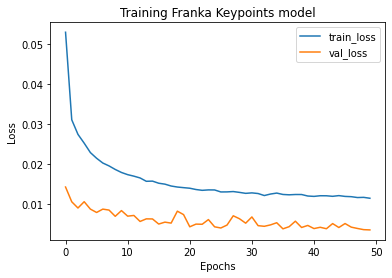

In [232]:
plt.plot(range(epochs), train_epoch, label="train_loss")
plt.plot(range(epochs), val_epoch, label="val_loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Franka Keypoints model")
plt.show()

torch.Size([3, 224, 224])
tensor([0.2806, 0.2676, 0.0921, 0.1219, 0.1065, 0.0813, 0.9103, 0.6459, 0.5098,
        0.4510, 0.1171, 0.0456], device='cuda:0', dtype=torch.float64)
tensor([0.2867, 0.2763, 0.0966, 0.1278, 0.1134, 0.0878, 0.9034, 0.6414, 0.5090,
        0.4527, 0.1246, 0.0433])
tensor([0.8601, 0.8290, 0.2899, 0.3833, 0.3402, 0.2633])
tensor([57.8185, 41.0484, 32.5756, 28.9735,  7.9715,  2.7735])
0.005396366119384766
<class 'torch.Tensor'>
(480, 640, 3)
(480, 640, 3)


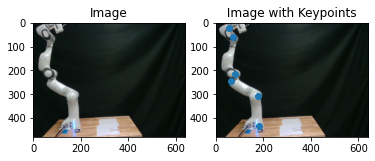

In [233]:
# Displaying the results
import time
test_dataset = KpDataset(test_df)
index = 0
test_img, points = test_dataset[index]
print(test_img.shape)
print(points)
s = time.time()
franka_key_points = model(test_img[None]).flatten().detach().cpu()
print(franka_key_points)

fkpy = franka_key_points[:6]*img.shape[1]
fkpx = franka_key_points[6:]*img.shape[0]

print(fkpy)
print(fkpx)

curr_time = (time.time()-s )
print(curr_time)
print(type(franka_key_points))
plt.subplot(121)
plt.title("Image")
img = test_dataset.load_img(index)
print(img.shape)
# img = img[:,:,::-1]
print(img.shape)
plt.imshow(img)
plt.subplot(122)
plt.title(" Image with Keypoints ")
plt.imshow(img)
plt.scatter(franka_key_points[:6]*img.shape[1], franka_key_points[6:]*img.shape[0])   # scaling the keypoints with image dimension
plt.show()

In [206]:
import cv2

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])
# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/2D_proj_ds/61.rgb.jpg')

img = cv2.imread('/home/jc-merlab/frame0000.jpg')

# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/test_img.jpg')

print(img.shape)

img_arr = img/255.0
img_arr = cv2.resize(img_arr, (224,224)) 
img_arr = torch.tensor(img_arr).permute(2,0,1) 
print(type(img_arr))
img_arr = normalize(img_arr).float()
img_arr = img_arr.to(device)
# img = list(img)


(480, 640, 3)
<class 'torch.Tensor'>


In [207]:
print(img_arr.shape)

torch.Size([3, 224, 224])


In [208]:
franka_key_points = model(img_arr[None]).flatten().detach().cpu()

print(franka_key_points)

fkpx = franka_key_points[:6]*img.shape[1]

print(fkpx)

fkpy = franka_key_points[6:]*img.shape[0]

print(fkpy)

tensor([0.4032, 0.3921, 0.4281, 0.4429, 0.5332, 0.5523, 0.7095, 0.5757, 0.4661,
        0.4778, 0.5206, 0.5228])
tensor([258.0250, 250.9134, 273.9579, 283.4762, 341.2757, 353.4586])
tensor([340.5829, 276.3520, 223.7130, 229.3544, 249.8885, 250.9201])


640


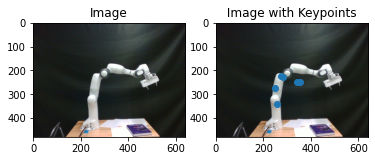

In [209]:
# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/2D_proj_ds/61.rgb.jpg')

# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/test_img.jpg')

img = cv2.imread('/home/jc-merlab/frame0000.jpg')
img = img[:,:,::-1] 
print(img.shape[1])
plt.subplot(121)
plt.title("Image")                                                        
plt.imshow(img)
plt.subplot(122)
plt.title(" Image with Keypoints ")
plt.imshow(img)
plt.scatter(franka_key_points[:6]*img.shape[1], franka_key_points[6:]*img.shape[0])   # scaling the keypoints with image dimension
plt.show()